🔄 Loading dataset from: Datasets/fake_social_media.csv...
⚙️ Preprocessing features...
📊 Training shape: (2400, 18) | Testing shape: (600, 18)
🤖 Training Random Forest Classifier...

📋 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       1.00      1.00      1.00       599

    accuracy                           1.00       600
   macro avg       0.50      0.50      0.50       600
weighted avg       1.00      1.00      1.00       600

🎨 Generating confusion matrix plot...
💾 Metrics diagram captured and saved as 'final_detection_report_plots.png'.


c:\Users\Krishnam Mavani\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Krishnam Mavani\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Krishnam Mavani\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beh

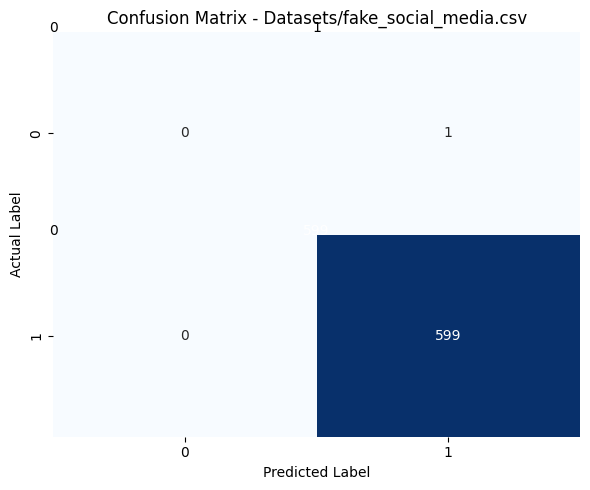

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# ==========================================
# 🎛️ CONFIGURATION: SET YOUR NEW DATASET HERE
# ==========================================
DATASET_PATH = "Datasets/fake_social_media.csv"  # <-- Change to your new file path (e.g., "new_data.csv")
TARGET_COLUMN = "is_fake"                # <-- Change to your new target column name

# List any categorical columns that need One-Hot Encoding
CATEGORICAL_COLUMNS = ["platform"]       # <-- Update based on your new dataset's columns
# ==========================================

print(f"🔄 Loading dataset from: {DATASET_PATH}...")
df = pd.read_csv(DATASET_PATH)

# 1. Handle Categorical Encoding Dynamically
print("⚙️ Preprocessing features...")
if CATEGORICAL_COLUMNS:
    # Safely filter only columns that exist in the dataframe
    valid_cat_cols = [col for col in CATEGORICAL_COLUMNS if col in df.columns]
    df_encoded = pd.get_dummies(df, columns=valid_cat_cols, drop_first=True)
else:
    df_encoded = df.copy()

# 2. Separate Features (X) and Target (y)
if TARGET_COLUMN not in df_encoded.columns:
    raise KeyError(f"❌ Target column '{TARGET_COLUMN}' not found in the dataset.")

X = df_encoded.drop(columns=[TARGET_COLUMN])
y = df_encoded[TARGET_COLUMN]

# 3. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"📊 Training shape: {X_train.shape} | Testing shape: {X_test.shape}")

# 4. Model Training
print("🤖 Training Random Forest Classifier...")
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 5. Evaluation
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

print("\n📋 CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred))

# 6. Visualization & Saving Plot
print("🎨 Generating confusion matrix plot...")
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)

# Overlay manual adjustments if needed (similar to your previous implementation)
for i, j in np.ndindex(cm.shape):
    plt.text(j, i, format(cm[i, j], 'd'),
             horizontalalignment="center",
             color="white" if cm[i, j] > cm.max()/2 else "black")

plt.title(f"Confusion Matrix - {DATASET_PATH}")
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.tight_layout()

# Save output automatically
output_filename = "final_detection_report_plots.png"
plt.savefig(output_filename, dpi=300)
print(f"💾 Metrics diagram captured and saved as '{output_filename}'.")
plt.show()